# Project: The Galactic Plane ($b = 0$)

Implements the deliverables of HI1.tex sec. 7:

1. Position-velocity image $T_B(\ell, v_{\rm LSR})$ at $b \sim 0$.
2. Inner-Galaxy rotation curve $V(R)$ via the tangent-point method
   (HI1.tex eq. (`vdopp`)).
3. Enclosed gravitational mass $M_{\rm grav}(R)$.
4. Gaseous mass $M_{\rm gas}(R)$ via HI1.tex eq. (`telemass1`),
   reported for both near and far kinematic-distance branches.
5. Spiral structure: a 4-arm log-spiral forward overlay (Reid+2014
   / Vallee 2017) and an independent pitch-angle fit to bright
   ridges in the $\ell$-$v$ image.
6. Galactic centre sightlines (loose BH-mass lower bound).

Inputs: `artifacts/scan_data_products.pkl` (calibrated pol-1 Stokes-I
$T_B$, plus the precomputed $W$ map and $\ell$-$v$ strip at $b\sim 0$).

**Calibration caveats** carried over from upstream: pol-1-only,
Stokes-I $= 2\,T_B^{\rm pol 1}$, $T_{\rm cal}^{\rm pol 1}(t)$ from the
EBHIS-anchored 24 h PDT Fourier model. Absolute scale carries the
EBHIS systematic.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import brentq, least_squares
from scipy.ndimage import maximum_filter, label

from plotters import (
    plot_lv_strip,
    plot_survey_mollweide,
    never_observable_mask,
)
from ugradiolab.plotting import (
    TEXTWIDTH_IN, landscapewidth_figure, subpanels,
    SS_FINE, SS_STANDARD, LW_FINE, LW_LIGHT,
    NEUTRAL_COLOR, ALPHA_FAINT, ALPHA_STANDARD,
)

# --- Astrophysical constants (HI1.tex line 777-778) ---
R_SUN_KPC   = 8.5
V_SUN_KMS   = 220.0
HPBW_DEG    = 3.4
OMEGA_B_SR  = 1.133 * np.deg2rad(HPBW_DEG) ** 2  # Gaussian beam solid angle [sr]

# --- Unit conversions ---
M_H_G       = 1.6735e-24          # hydrogen mass [g]
KPC_CM      = 3.0857e21           # 1 kpc in cm
M_SUN_G     = 1.989e33            # solar mass [g]
G_KPC       = 4.302e-6            # G in kpc (km/s)^2 / M_sun
NH_TO_TBKMS = 1.823e18            # N_HI [cm^-2] = this * W [K km/s]

# --- Paths ---
PRODUCTS_PATH = Path('artifacts/scan_data_products.pkl')
OUTPUT_PATH   = Path('artifacts/galactic_plane_products.pkl')

# --- Rotation-curve envelope extraction ---
NSIGMA_ENVELOPE = 5.0    # diagnostic only (Burton 25%-of-peak isophote is used)
NOISE_V_LO_KMS  = -160.0
NOISE_V_HI_KMS  = -120.0

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load `scan_data_products.pkl`

In [2]:
with open(PRODUCTS_PATH, 'rb') as f:
    products = pickle.load(f)

cells_data    = products['cells']
v_lsr         = products['v_lsr_overlap']
dv_kms        = float(products['dv_kms'])
W_dict        = products['W']
lv_strip      = products['lv_strip']
moll_center_l = float(products['moll_center_l'])

l_fine   = lv_strip['l_fine']
lv_image = lv_strip['lv_image']            # shape (nv, n_l), K
sigma_kernel_deg = float(lv_strip['sigma_deg'])
b_max_strip_deg  = float(lv_strip['b_max_deg'])

print(f'Loaded {PRODUCTS_PATH} ({PRODUCTS_PATH.stat().st_size/1e6:.2f} MB)')
print(f'  {len(cells_data)} cells, dv = {dv_kms:.3f} km/s, '
      f'v_LSR span [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s')
print(f'  l-v strip: l in [{l_fine[0]:.1f}, {l_fine[-1]:.1f}] deg '
      f'({len(l_fine)} bins), sigma_kernel = {sigma_kernel_deg:.2f} deg, '
      f'|b| <= {b_max_strip_deg:.1f} deg')

Loaded artifacts/scan_data_products.pkl (22.05 MB)
  2652 cells, dv = 0.660 km/s, v_LSR span [-164, 132] km/s
  l-v strip: l in [-90.0, 270.0] deg (721 bins), sigma_kernel = 1.44 deg, |b| <= 4.0 deg


## 2. Position-velocity image $T_B(\ell, v_{\rm LSR})$ at $b \sim 0$

The primary deliverable from HI1.tex sec. 7. Reused directly from the
calibrated `lv_strip` (sec. 6b of `main_scan_data_products.ipynb`).

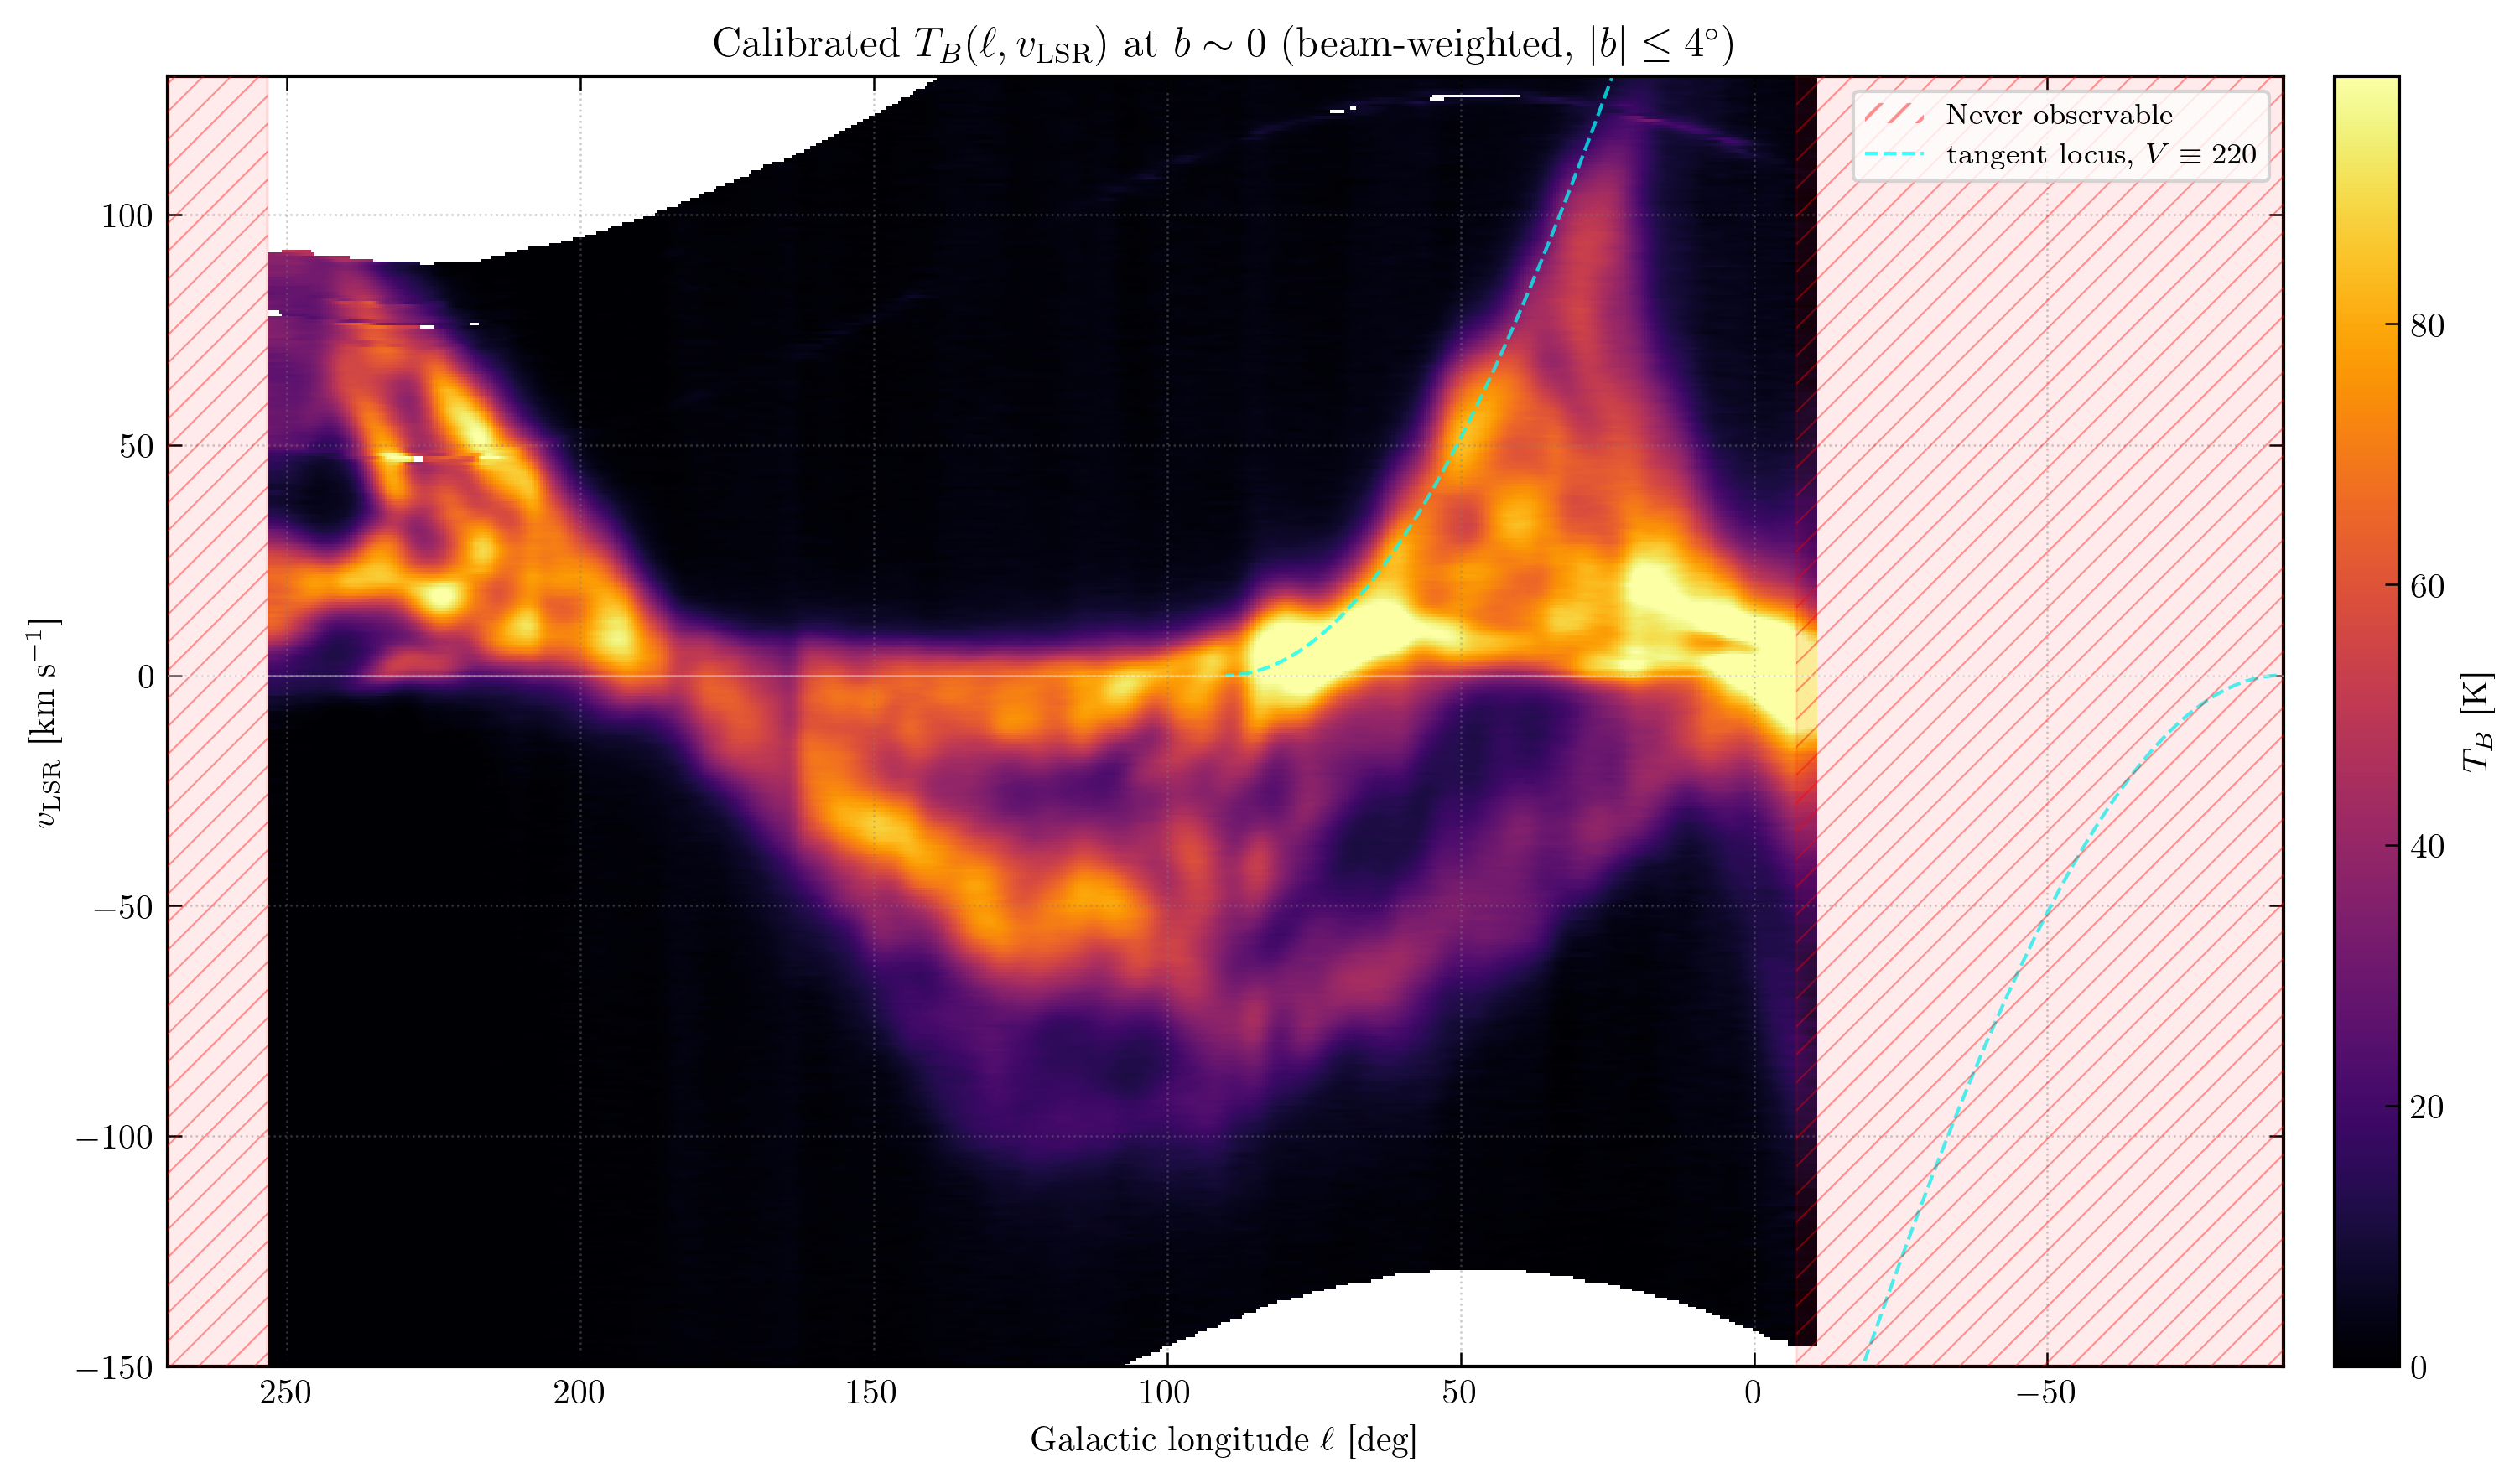

In [3]:
fig, ax = plot_lv_strip(
    l_fine, v_lsr, lv_image,
    title=(r'Calibrated $T_B(\ell, v_{\rm LSR})$ at $b \sim 0$  '
           rf'(beam-weighted, $|b| \le {b_max_strip_deg:.0f}^\circ$)'),
    cbar_label=r'$T_B$ [K]',
)
ax.axhline(0.0, color='w', lw=LW_FINE, alpha=ALPHA_FAINT, zorder=4)

# Tangent-point locus: V_LSR^max(l) = V(R_t) - V_sun sin(l) under the
# circular-rotation assumption, with R_t = R_sun sin(l).  We plot the
# IAU-flat (V_220) version for reference; the fitted curve is overlaid
# in section 3 below.
l_tp = np.linspace(0.0, 90.0, 181)
V_tp_flat = V_SUN_KMS * (1.0 - np.abs(np.sin(np.deg2rad(l_tp))))
ax.plot(l_tp, V_tp_flat, color='cyan', lw=LW_LIGHT, ls='--',
        alpha=ALPHA_STANDARD, label=r'tangent locus, $V \equiv 220$')
ax.plot(-l_tp, -V_tp_flat, color='cyan', lw=LW_LIGHT, ls='--',
        alpha=ALPHA_STANDARD)
ax.legend(loc='upper right', fontsize='small')
plt.show()

### Why the tangent locus is drawn only for $|\ell| < 90^\circ$

For $\ell \in (90^\circ, 270^\circ)$ the tangent-point construction does
not apply. Those sightlines look toward the outer Galaxy (or through
the anticenter), where every point along the line of sight has
$R \ge R_\odot$ and there is no tangent point inside the solar circle.
The relation
$$
V_{\rm LSR}^{\max}(\ell) = V(R_t) - V_\odot\,\sin\ell,
\qquad R_t = R_\odot\,|\sin\ell|,
$$
is only meaningful for $|\ell| < 90^\circ$, which is why the cyan locus
above is drawn only on $\ell \in [-90^\circ, +90^\circ]$ and why
section 3 further restricts the rotation-curve extraction to
$|\ell| \in [20^\circ, 65^\circ]$ (avoiding the Galactic-centre
degeneracy at small $\ell$ and the $R_t \to R_\odot$ blow-up near
$\ell = \pm 90^\circ$).

In the outer Galaxy, $v_{\rm LSR}$ along a sightline is monotonic in
distance under circular rotation, so converting $v_{\rm LSR}$ to $R$
requires an independent distance (kinematic distances using an assumed
$V(R)$, or stellar associations). There is no envelope trick. The
outer-Galaxy half of the $\ell$-$v$ strip is shown above for
completeness but is not used to constrain $V(R)$.

## 3. Inner-Galaxy rotation curve (tangent-point method)

For $|\ell| < 90^\circ$ the maximum LSR velocity along a sightline is reached
at the tangent point $R_t = R_\odot |\sin\ell|$.  Applying HI1.tex
eq. (\ref{vdopp}) at $R = R_t$ inverts to

$$
V(R_t) \;=\; |v_{\rm LSR}^{\max}(\ell)| \;+\; V_\odot\,|\sin\ell|.
$$

We extract $v_{\rm LSR}^{\max}(\ell)$ from the calibrated $T_B(\ell, v)$
strip using the classical Burton fractional-of-peak envelope rule:
$v_{\rm LSR}^{\max}$ is the most extreme velocity at which
$T_B(v) > f\,T_{\rm peak}(\ell)$, with $f = 0.25$.  This is the recipe
introduced by Burton (1971; 1988) and inherited by most subsequent
tangent-point analyses (e.g. Clemens 1985, Levine, Heiles & Blitz 2008).
We restrict to $|\ell| \in [20^\circ, 65^\circ]$ to avoid the
Galactic-centre degeneracy at small $\ell$ and the $R_t \to R_\odot$
blow-up near $|\ell| \sim 90^\circ$.

For comparison we overlay the Brand & Blitz (1993) power-law fit
$V(R)/V_\odot = a_1 (R/R_\odot)^{a_2} + a_3$ with
$(a_1, a_2, a_3) = (1.00767,\, 0.0394,\, 0.00712)$ and the standard IAU
solar values $(V_\odot, R_\odot) = (220\,{\rm km/s},\, 8.5\,{\rm kpc})$.

**References**

* Burton, W. B. 1971, *A\&A* 10, 76 -- introduces the fractional-of-peak
  terminal-velocity recipe for HI tangent points.
* Burton, W. B. 1988, "The Structure of Our Galaxy Derived from
  Observations of Neutral Hydrogen," in *Galactic and Extragalactic
  Radio Astronomy*, 2nd ed., eds. G. L. Verschuur & K. I. Kellermann
  (Berlin: Springer), pp. 295-358 -- review chapter cited by HI1.tex.
* Clemens, D. P. 1985, *ApJ* 295, 422 -- Massachusetts-Stony Brook CO
  survey tangent-point analysis, an early high-resolution check of the
  Burton recipe.
* Levine, E. S., Heiles, C., & Blitz, L. 2008, *ApJ* 679, 1288 --
  modern HI application of the same envelope idea.
* Brand, J., & Blitz, L. 1993, *A\&A* 275, 67 -- the reference rotation
  curve plotted as the dashed grey line below.


sigma_TB (median over l, off-line v window): 0.43 K


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


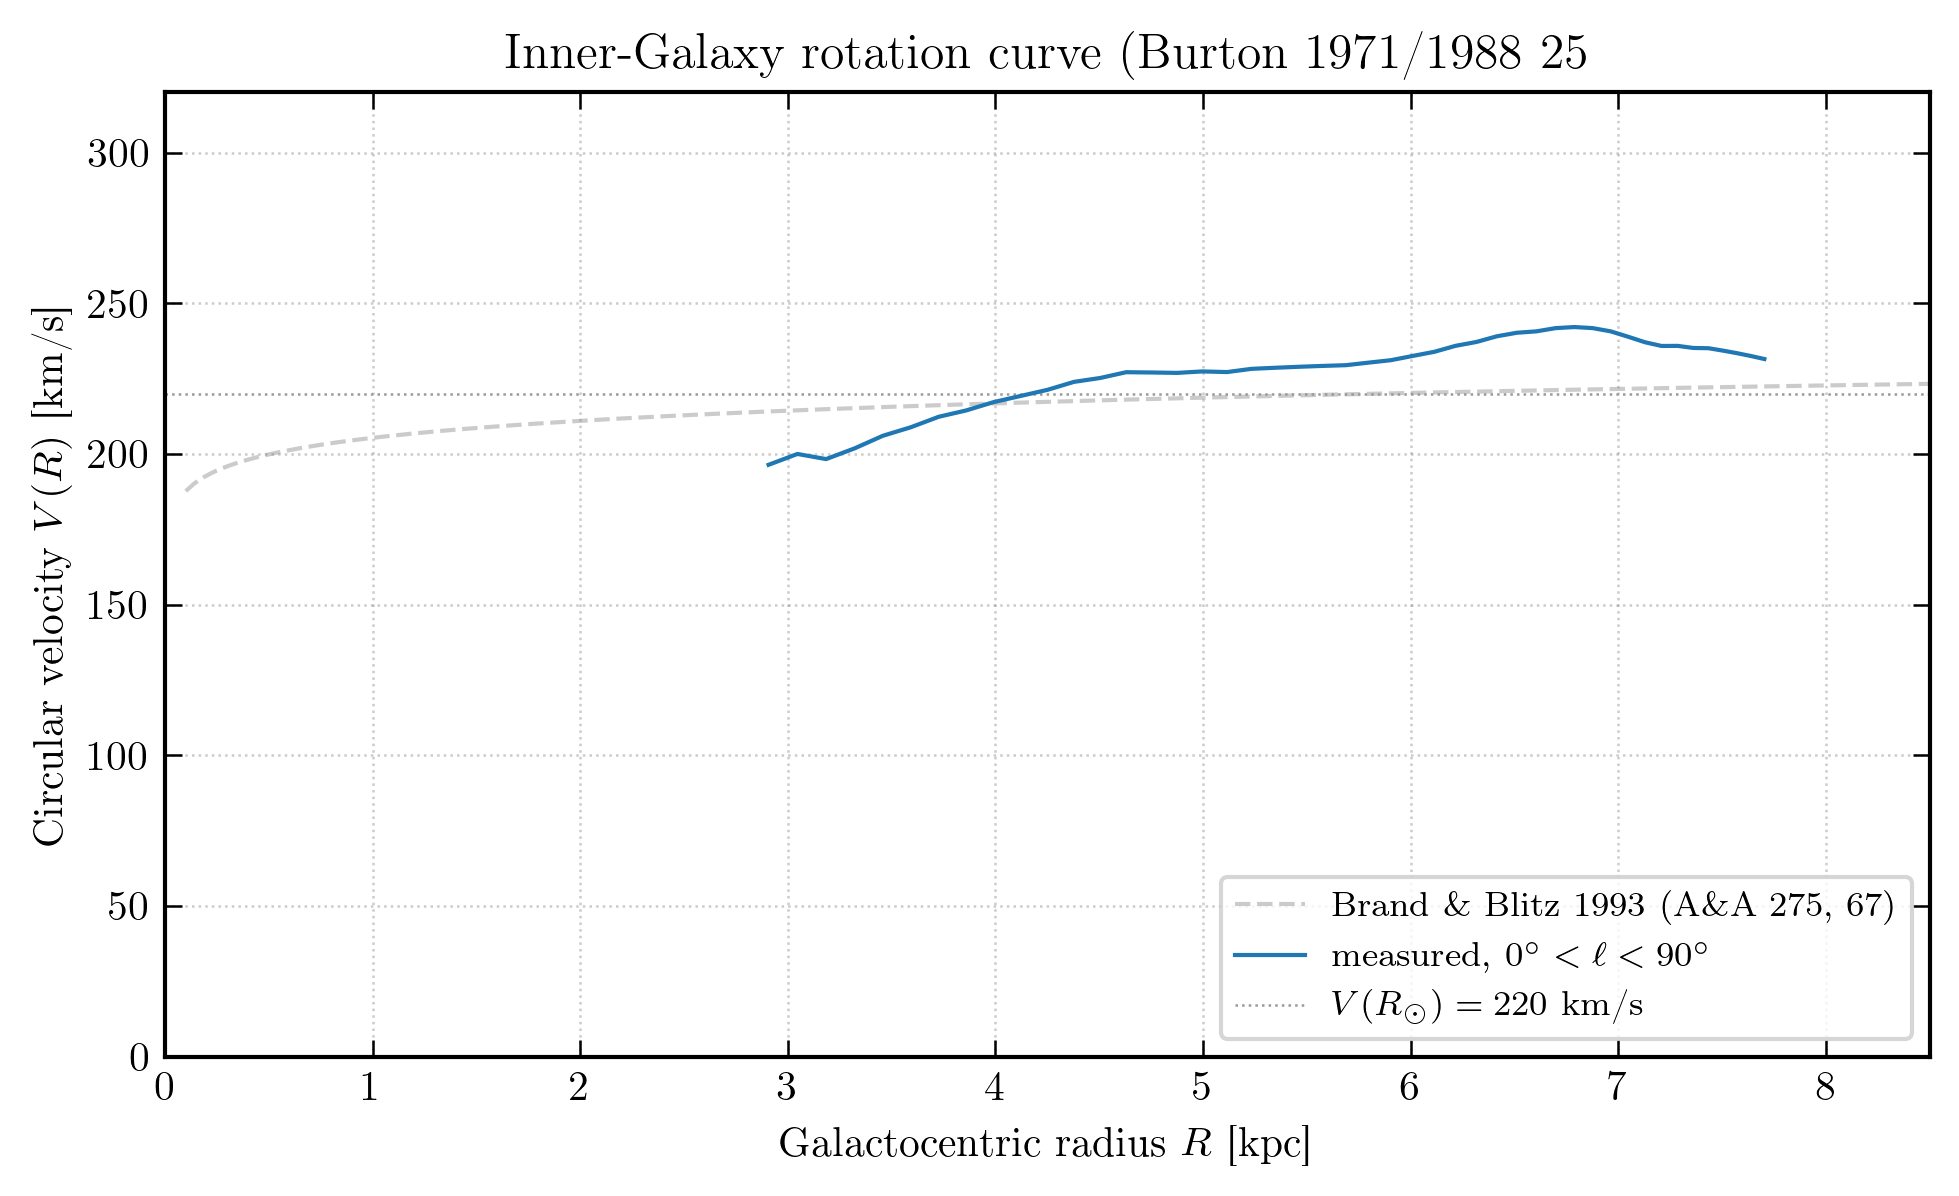

extracted 46 tangent points (Q1 only; Leuschner coverage)


In [4]:
# Off-line noise estimate per longitude column (reported for context only;
# not used in the envelope rule).
noise_mask = (v_lsr >= NOISE_V_LO_KMS) & (v_lsr <= NOISE_V_HI_KMS)
sigma_per_l = np.nanstd(lv_image[noise_mask, :], axis=0)
sigma_median = float(np.nanmedian(sigma_per_l))
print(f'sigma_TB (median over l, off-line v window): {sigma_median:.2f} K')

# --- Burton (1971, 1988) 25%-of-peak terminal-velocity envelope --------------
FRAC_OF_PEAK   = 0.25
L_TP_MIN_DEG   = 20.0
L_TP_MAX_DEG   = 65.0
V_BAND_MAX_KMS = 130.0


def envelope_v(l_target, sign='max'):
    j = int(np.argmin(np.abs(l_fine - l_target)))
    spec = lv_image[:, j]
    if not np.isfinite(spec).any():
        return np.nan
    spec_clean = np.where(np.isfinite(spec), spec, 0.0)
    edge_ok = np.abs(v_lsr) < V_BAND_MAX_KMS
    spec_use = np.where(edge_ok, spec_clean, -np.inf)
    T_peak = float(np.nanmax(spec_use))
    if T_peak <= 0:
        return np.nan
    above = (spec_use > FRAC_OF_PEAK * T_peak) & edge_ok
    if not above.any():
        return np.nan
    v_above = v_lsr[above]
    return float(v_above.max()) if sign == 'max' else float(v_above.min())


def tangent_VR(l_deg, v_env):
    sinl = np.abs(np.sin(np.deg2rad(l_deg)))
    return R_SUN_KPC * sinl, np.abs(v_env) + V_SUN_KMS * sinl


l_grid_Q1 = np.arange(L_TP_MIN_DEG, L_TP_MAX_DEG + 1, 1.0)
v_env_Q1 = np.array([envelope_v(l, 'max') for l in l_grid_Q1])
ok_Q1 = np.isfinite(v_env_Q1)
R_Q1, V_Q1 = tangent_VR(l_grid_Q1[ok_Q1], v_env_Q1[ok_Q1])


def V_brand_blitz(R):
    a1, a2, a3 = 1.00767, 0.0394, 0.00712
    return V_SUN_KMS * (a1 * (R / R_SUN_KPC) ** a2 + a3)


R_lit = np.linspace(0.1, R_SUN_KPC, 200)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.55))
ax.plot(R_lit, V_brand_blitz(R_lit),
        color=NEUTRAL_COLOR, lw=LW_LIGHT, ls='--', alpha=ALPHA_FAINT,
        label=r'Brand \& Blitz 1993 (A\&A 275, 67)')
ax.plot(R_Q1, V_Q1, color='C0', lw=LW_LIGHT, zorder=3,
        label=r'measured, $0^\circ < \ell < 90^\circ$')
ax.axhline(V_SUN_KMS, color='0.6', lw=LW_FINE, ls=':',
           label=rf'$V(R_\odot) = {V_SUN_KMS:.0f}$ km/s')
ax.axvline(R_SUN_KPC, color='0.6', lw=LW_FINE, ls=':')
ax.set_xlabel(r'Galactocentric radius $R$ [kpc]')
ax.set_ylabel(r'Circular velocity $V(R)$ [km/s]')
ax.set_xlim(0, R_SUN_KPC)
ax.set_ylim(0, 320)
ax.legend(loc='lower right', fontsize='small')
ax.set_title(rf'Inner-Galaxy rotation curve  '
             rf'(Burton 1971/1988 {FRAC_OF_PEAK:.0%}-of-peak, '
             rf'$\ell\in[{L_TP_MIN_DEG:.0f}, {L_TP_MAX_DEG:.0f}]^\circ$)')
plt.show()

print(f'extracted {R_Q1.size} tangent points (Q1 only; Leuschner coverage)')


## 4. Enclosed gravitational mass $M_{\rm grav}(R)$

Assuming spherical symmetry and circular orbits, HI1.tex line 437 gives the
enclosed gravitational mass directly from the rotation curve,
$$
M_{\rm grav}(R) \;=\; \frac{V(R)^2\,R}{G}.
$$
We evaluate this at every tangent-point measurement from section 3, so the
result is a radial profile, not a single number at $R_\odot$. The dashed
faded curve is the same expression applied to the Brand & Blitz (1993)
rotation curve for comparison.


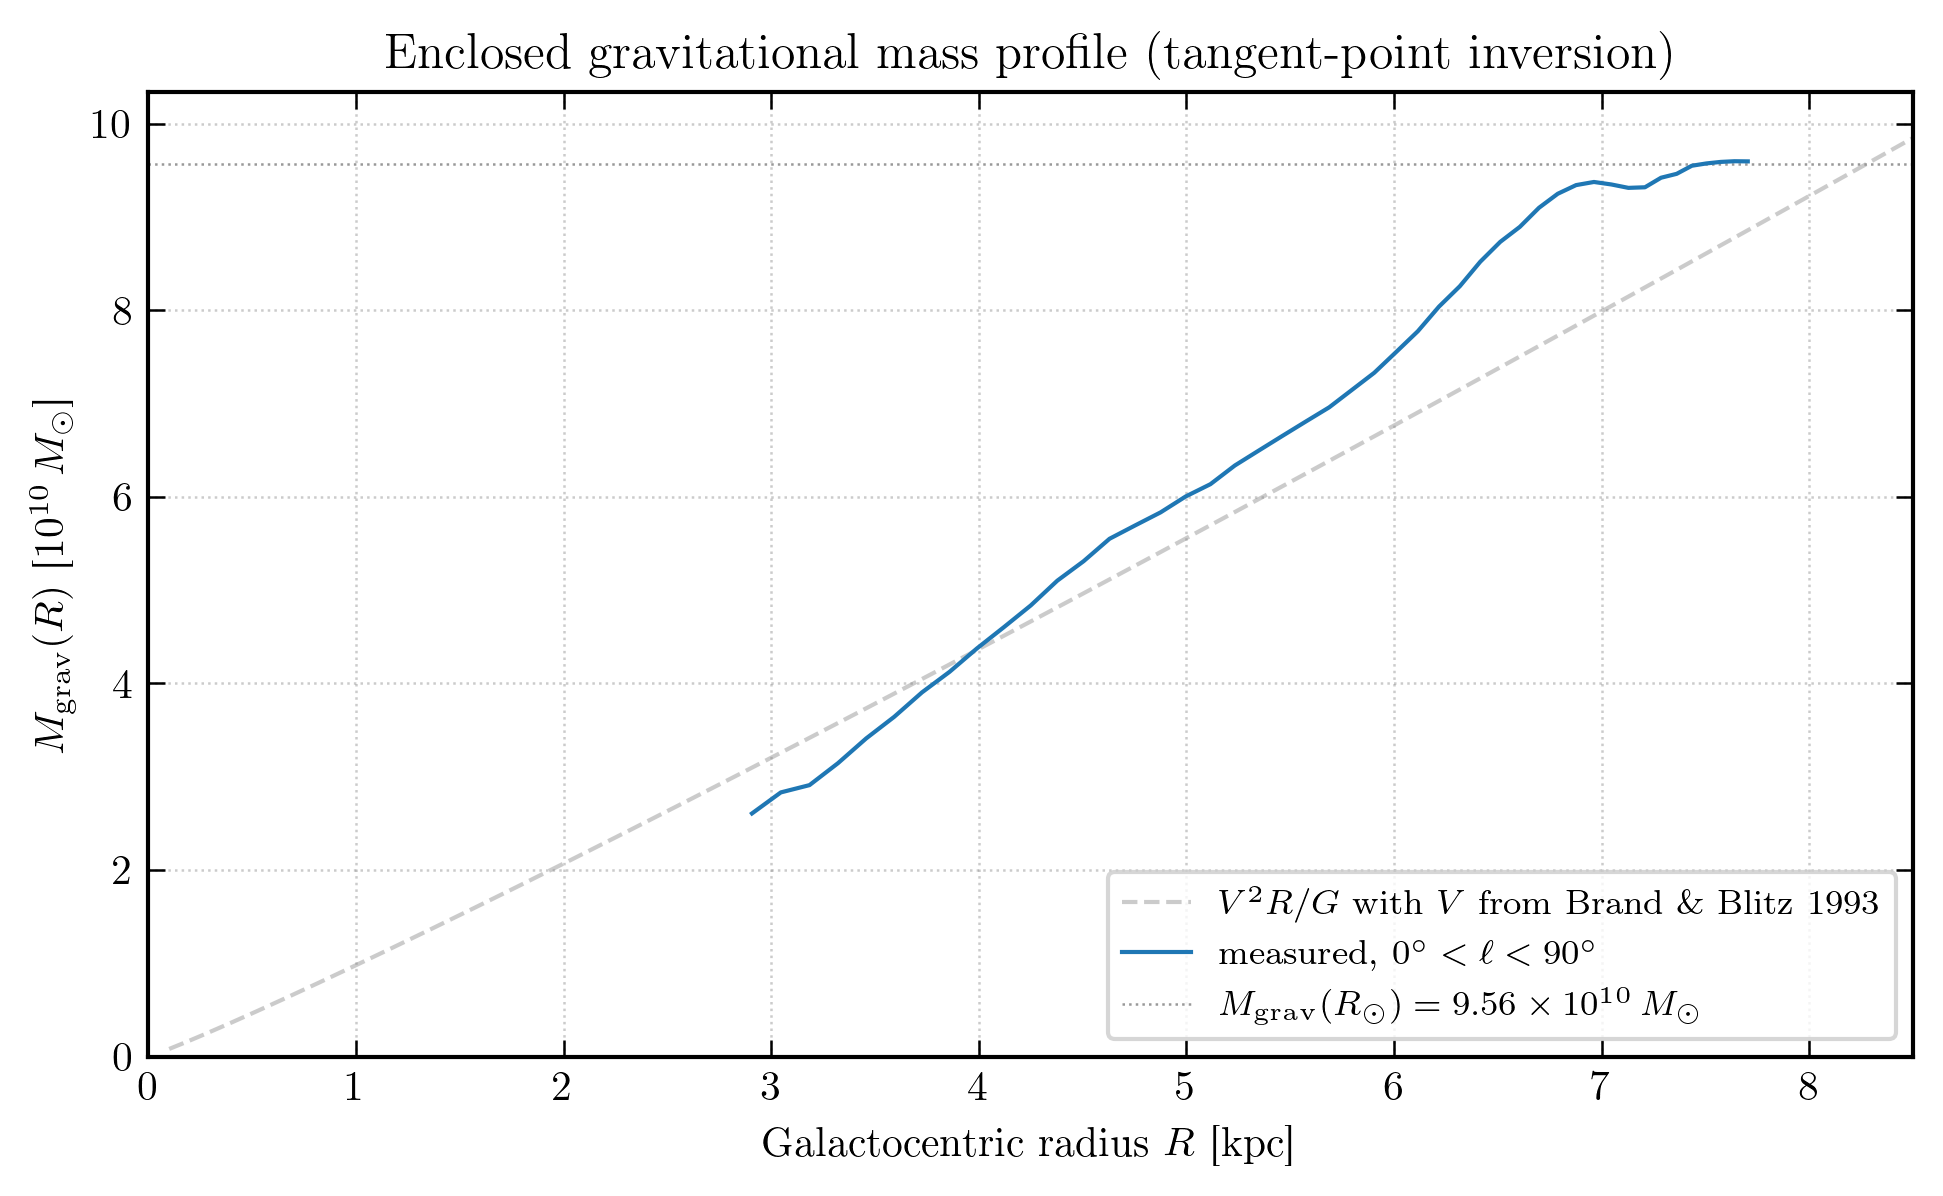

M_grav at R_sun (IAU anchor):  9.563e+10 M_sun  = 9.56e10 M_sun
M_grav range (measured):       [2.61, 9.60] x 1e10 M_sun


In [5]:
# Enclosed gravitational mass at each tangent point:  M = V^2 R / G.
# G_KPC has units kpc (km/s)^2 / M_sun, so V^2 R / G yields M_sun directly.
M_grav_Q1 = V_Q1 ** 2 * R_Q1 / G_KPC

M_grav_lit = V_brand_blitz(R_lit) ** 2 * R_lit / G_KPC

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.55))
ax.plot(R_lit, M_grav_lit / 1e10,
        color=NEUTRAL_COLOR, lw=LW_LIGHT, ls='--', alpha=ALPHA_FAINT,
        label=r'$V^2 R / G$ with $V$ from Brand \& Blitz 1993')
ax.plot(R_Q1, M_grav_Q1 / 1e10, color='C0', lw=LW_LIGHT, zorder=3,
        label=r'measured, $0^\circ < \ell < 90^\circ$')
M_sun_anchor = V_SUN_KMS ** 2 * R_SUN_KPC / G_KPC
ax.axhline(M_sun_anchor / 1e10, color='0.6', lw=LW_FINE, ls=':',
           label=(rf'$M_{{\rm grav}}(R_\odot) = '
                  rf'{M_sun_anchor/1e10:.2f}\times 10^{{10}}\,M_\odot$'))
ax.axvline(R_SUN_KPC, color='0.6', lw=LW_FINE, ls=':')
ax.set_xlabel(r'Galactocentric radius $R$ [kpc]')
ax.set_ylabel(r'$M_{\rm grav}(R)$ [$10^{10}\,M_\odot$]')
ax.set_xlim(0, R_SUN_KPC)
ax.set_ylim(bottom=0)
ax.legend(loc='lower right', fontsize='small')
ax.set_title(r'Enclosed gravitational mass profile (tangent-point inversion)')
plt.show()

print(f'M_grav at R_sun (IAU anchor):  '
      f'{M_sun_anchor:.3e} M_sun  = {M_sun_anchor/1e10:.2f}e10 M_sun')
print(f'M_grav range (measured):       '
      f'[{M_grav_Q1.min()/1e10:.2f}, {M_grav_Q1.max()/1e10:.2f}] '
      f'x 1e10 M_sun')


## 5. Gaseous mass $M_{\rm gas}(R)$ via eq. (\ref{telemass1})

HI1.tex eq. (\ref{telemass1}) gives the HI mass seen by the telescope per
velocity channel:
$$
M_{HI}(v) \;=\; 1.8\times 10^{18}\,\Delta v\,d^{2}\,m_H\,T_A\,\Omega_b
\quad [\mathrm{gm,\,cgs}].
$$
For each $(l, v)$ pixel of the $b\sim 0$ strip we apply this expression,
converting the LSR velocity to a galactocentric radius via the rotation
curve from section 3 and HI1.tex eq. (\ref{vdopp}). At a given Q1
longitude the inversion is one-to-one in $R$, but the distance
$d$ along the sightline is *not*: an inner-Galaxy radius
$R_t \le R \le R_\odot$ corresponds to two heliocentric distances
$$
d_\pm(l, R) \;=\; R_\odot\cos\ell \;\pm\; \sqrt{R^{2}-R_\odot^{2}\sin^{2}\ell},
$$
the classical **near/far kinematic-distance ambiguity** inside the solar
circle. The lab manual flags this on line 440. We accumulate the mass
twice -- once with $d_{-}$ (near) and once with $d_{+}$ (far) -- and
report both as separate radial profiles. The two branches bracket the
true gas distribution.

We sample $\ell$ at $2^{\circ}$ spacing (Nyquist for the
$\mathrm{HPBW} = 3.4^{\circ}$ beam, per HI1.tex
\S\,\ref{sampling}) over the same Q1 window
$\ell \in [20^{\circ}, 65^{\circ}]$ used to derive $V(R)$, so the
$V(R)$ interpolation is never extrapolated. Outside that window the
rotation curve is not measured.

**Caveats.** The $1.8\times 10^{18}$ relation assumes optically thin HI
(HI1.tex lines 645-647); in the Galactic plane $\tau$ is order unity in
some directions, so $M_{\rm gas}$ is a *lower bound*. Likewise we only
sample $b\sim 0$, so this is the gas mass seen along the
$b=0$ strip, not the full Galactic-disk gas mass.


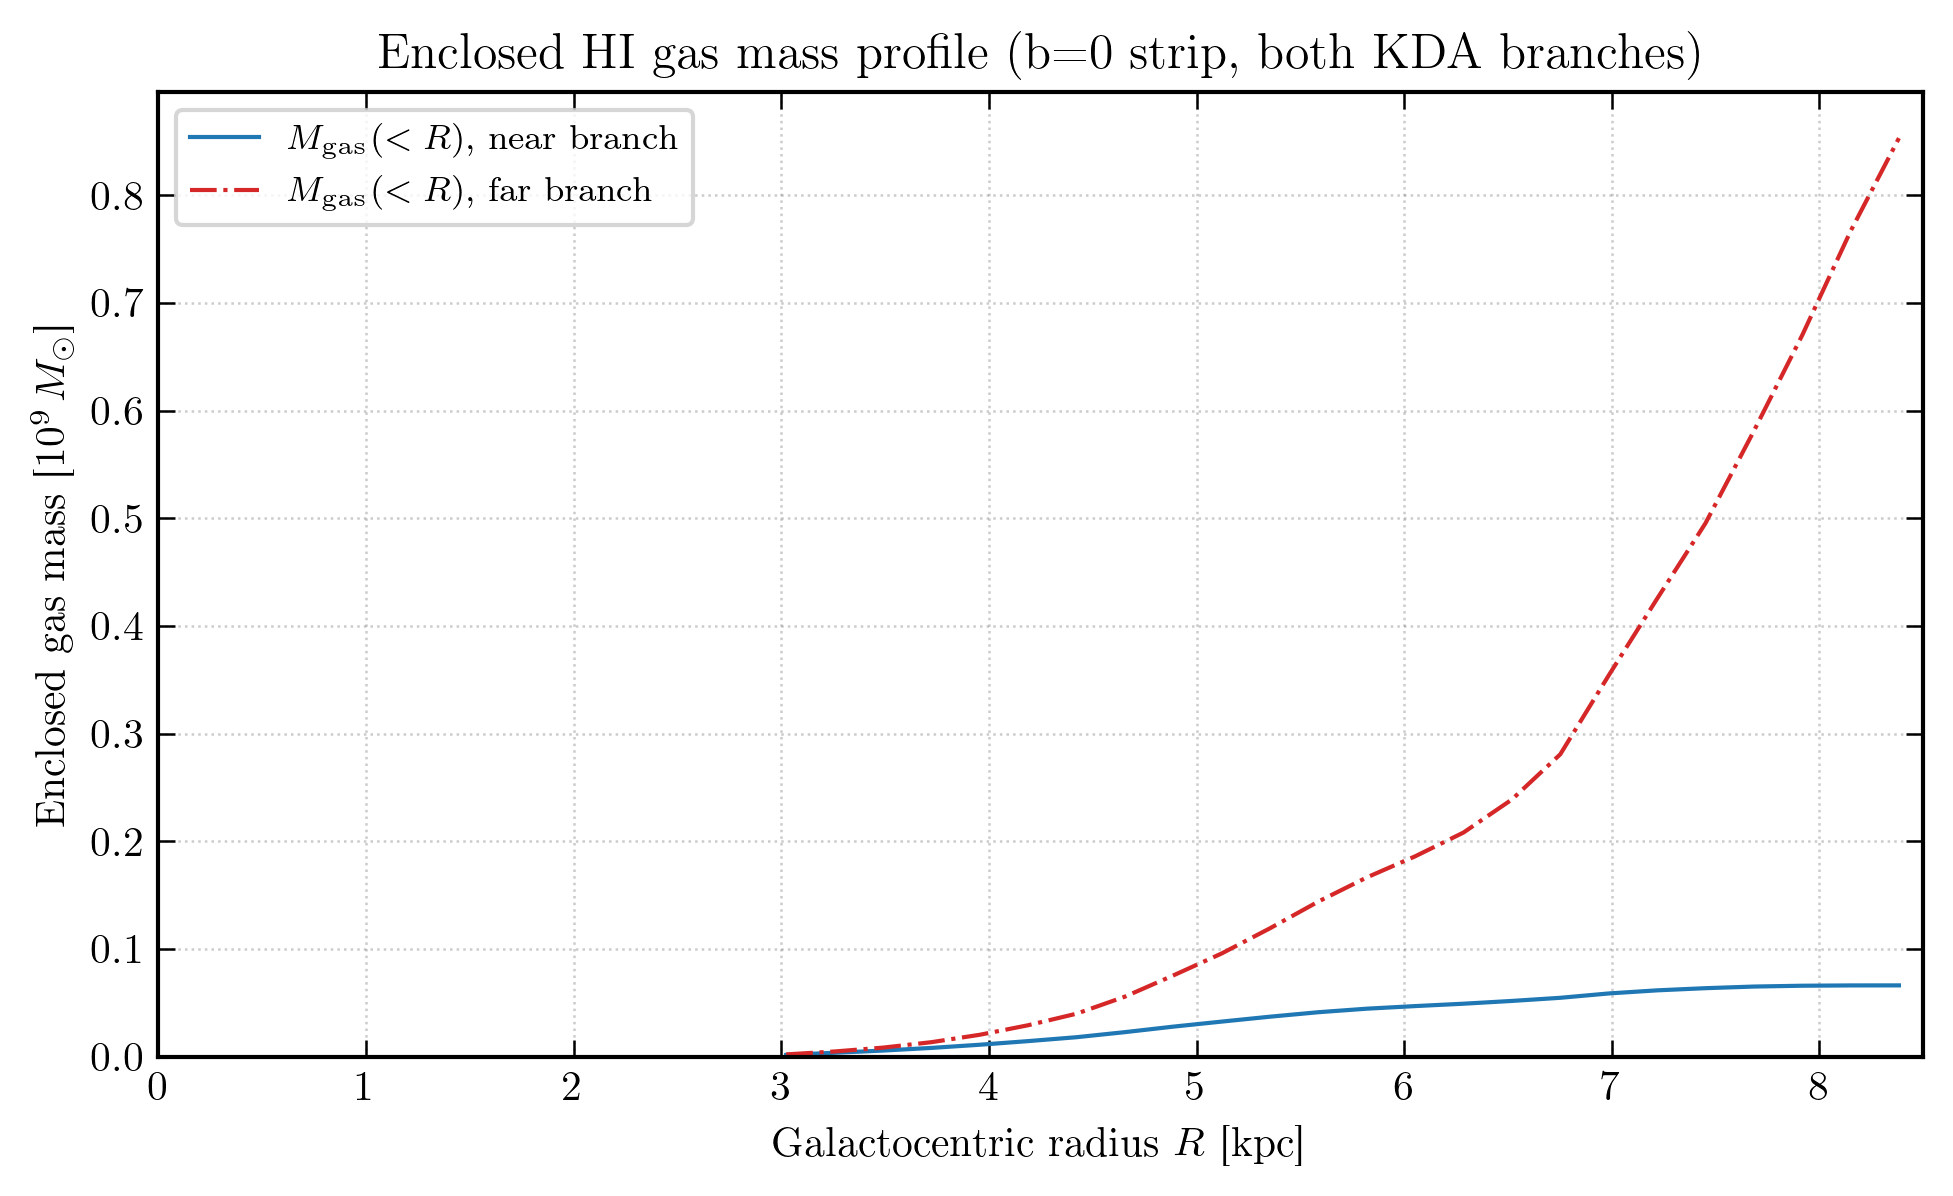

Inner-Galaxy gas mass (b=0 strip), near branch: 0.07 x 1e9 M_sun
Inner-Galaxy gas mass (b=0 strip), far  branch: 0.85 x 1e9 M_sun
Gravitational mass at R_sun (IAU anchor):       9.56 x 1e10 M_sun

M_gas / M_grav(R_sun):
  near branch: 0.069 %
  far  branch: 0.892 %

Note: M_gas here covers only the b=0 strip and assumes optically thin HI.
The true Galactic gas fraction is larger after integrating over b and tau.


In [6]:
# --- Inner-Galaxy V(R) interpolator (sorted by construction) -----------------
R_for_interp = np.append(R_Q1, R_SUN_KPC)
V_for_interp = np.append(V_Q1, V_SUN_KMS)
R_INVERT_MIN = float(R_Q1.min())


def V_interp(R):
    return np.interp(R, R_for_interp, V_for_interp)


def v_lsr_model(R, l_rad):
    return (V_interp(R) / R - V_SUN_KMS / R_SUN_KPC) * R_SUN_KPC * np.sin(l_rad)


# --- Sampling and binning ----------------------------------------------------
L_SAMPLE_STEP_DEG = 2.0
l_sample_deg = np.arange(L_TP_MIN_DEG, L_TP_MAX_DEG + 1e-9, L_SAMPLE_STEP_DEG)

R_bin_edges   = np.linspace(R_INVERT_MIN, R_SUN_KPC, 25)
R_bin_centers = 0.5 * (R_bin_edges[:-1] + R_bin_edges[1:])

M_gas_near_bin = np.zeros_like(R_bin_centers)
M_gas_far_bin  = np.zeros_like(R_bin_centers)

# Mass prefactor: N_HI = NH_TO_TBKMS * T_B * dv [cm^-2], then
# M_channel = N_HI * m_H * d_cm^2 * Omega_b, finally / M_SUN_G.
PREFACTOR = NH_TO_TBKMS * M_H_G * OMEGA_B_SR / M_SUN_G   # M_sun / (K * km/s * cm^2)

# --- Loop over Q1 pointings on the 2-deg grid --------------------------------
R_fine = np.linspace(R_INVERT_MIN, R_SUN_KPC - 1e-6, 1000)

for l_deg in l_sample_deg:
    l_rad = np.deg2rad(l_deg)
    j     = int(np.argmin(np.abs(l_fine - l_deg)))
    spec  = lv_image[:, j]
    sin_l, cos_l = np.sin(l_rad), np.cos(l_rad)

    # Inverse mapping v -> R on a fine R grid (v monotonic decreasing in R).
    v_at_R = v_lsr_model(R_fine, l_rad)
    v_sorted = v_at_R[::-1]
    R_sorted = R_fine[::-1]
    v_max_for_l = float(np.nanmax(v_at_R))

    valid = np.isfinite(spec) & (spec > 0) & (v_lsr > 0) & (v_lsr <= v_max_for_l)
    if not valid.any():
        continue

    v_use = v_lsr[valid]
    T_use = spec[valid]

    R_solved = np.interp(v_use, v_sorted, R_sorted)
    disc = R_solved**2 - R_SUN_KPC**2 * sin_l**2
    disc = np.clip(disc, 0.0, None)
    sqrt_disc = np.sqrt(disc)
    d_near_kpc = R_SUN_KPC * cos_l - sqrt_disc
    d_far_kpc  = R_SUN_KPC * cos_l + sqrt_disc

    d_near_cm = d_near_kpc * KPC_CM
    d_far_cm  = d_far_kpc  * KPC_CM

    m_near = PREFACTOR * T_use * dv_kms * d_near_cm**2
    m_far  = PREFACTOR * T_use * dv_kms * d_far_cm**2

    bin_ix = np.searchsorted(R_bin_edges, R_solved) - 1
    keep = (bin_ix >= 0) & (bin_ix < len(R_bin_centers))
    for bi, mn, mf in zip(bin_ix[keep], m_near[keep], m_far[keep]):
        M_gas_near_bin[bi] += mn
        M_gas_far_bin[bi]  += mf

# Enclosed (cumulative) gas mass.
M_gas_near_enc = np.cumsum(M_gas_near_bin)
M_gas_far_enc  = np.cumsum(M_gas_far_bin)

# Enclosed gravitational mass on the same radial grid.
M_grav_enc = V_interp(R_bin_centers) ** 2 * R_bin_centers / G_KPC

# --- Plot --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.55))
ax.plot(R_bin_centers, M_gas_near_enc / 1e9, color='C0', lw=LW_LIGHT,
        label=r'$M_{\rm gas}(<R)$, near branch')
ax.plot(R_bin_centers, M_gas_far_enc / 1e9, color='C3', lw=LW_LIGHT, ls='-.',
        label=r'$M_{\rm gas}(<R)$, far branch')
ax.set_xlabel(r'Galactocentric radius $R$ [kpc]')
ax.set_ylabel(r'Enclosed gas mass [$10^{9}\,M_\odot$]')
ax.set_xlim(0, R_SUN_KPC)
ax.set_ylim(bottom=0)
ax.axvline(R_SUN_KPC, color='0.6', lw=LW_FINE, ls=':')
ax.legend(loc='upper left', fontsize='small')
ax.set_title(r'Enclosed HI gas mass profile (b=0 strip, both KDA branches)')
plt.show()

# --- Report numbers ----------------------------------------------------------
M_gas_near_tot = M_gas_near_enc[-1]
M_gas_far_tot  = M_gas_far_enc[-1]
M_grav_at_Rsun = V_SUN_KMS**2 * R_SUN_KPC / G_KPC

print(f'Inner-Galaxy gas mass (b=0 strip), near branch: '
      f'{M_gas_near_tot/1e9:.2f} x 1e9 M_sun')
print(f'Inner-Galaxy gas mass (b=0 strip), far  branch: '
      f'{M_gas_far_tot /1e9:.2f} x 1e9 M_sun')
print(f'Gravitational mass at R_sun (IAU anchor):       '
      f'{M_grav_at_Rsun/1e10:.2f} x 1e10 M_sun')
print()
print(f'M_gas / M_grav(R_sun):')
print(f'  near branch: {M_gas_near_tot / M_grav_at_Rsun * 100:.3f} %')
print(f'  far  branch: {M_gas_far_tot  / M_grav_at_Rsun * 100:.3f} %')
print()
print('Note: M_gas here covers only the b=0 strip and assumes optically thin HI.')
print('The true Galactic gas fraction is larger after integrating over b and tau.')


## 6. Spiral structure: 2-arm data-driven log-spiral fit

HI1.tex \S\,\ref{galacticplane} (lines 453-481) asks us to project a
log-spiral arm $R_{\rm arm}(\phi) = R_{0}\,e^{\kappa(\phi - \phi_{0})}$
into $\ell$-$v$ space. We extract ridge points directly from the
calibrated $T_B(\ell, v)$ image **at all available longitudes** in the
survey, not just the Q1 tangent-point window, and fit two log spirals:

1. **Ridge extraction.** At each $\ell$ on a $2^\circ$ Nyquist grid
   spanning the full $l_{\rm fine}$ range, take the two highest local
   maxima of $T_B(v)$ separated by at least 10 km/s and above 10% of the
   column peak.
2. **Kinematic inversion.** Each $(\ell, v_{\rm peak})$ inverts to a
   galactocentric radius via eq. (\ref{vdopp}) with the full-disk
   rotation curve (measured $V(R)$ inside $R_\odot$, flat $V_\odot$
   outside per HI1.tex line 466). The corresponding heliocentric
   distance is the near branch when $R < R_\odot$ and the unique
   positive solution when $R \ge R_\odot$.
3. **Two-arm split.** For each longitude the smaller-$R$ peak is
   assigned to **arm A**, the larger-$R$ peak to **arm B**. This is a
   consistent geometric criterion across all four quadrants (unlike
   "higher-$v$ vs lower-$v$", whose meaning flips between Q1/Q4 and
   Q2/Q3).
4. **Log-spiral fit.** $\ln R = \ln R_{0} + \kappa\,\phi$ is linear, so
   OLS of $\ln R$ vs $\phi$ gives $(\kappa, R_{0})$ for each arm. Pitch
   angle $= \arctan\kappa$.
5. **Forward projection.** Each fitted spiral is re-projected back
   through eq. (\ref{vdopp}) and overlaid on the $T_B(\ell, v)$ image.

**Caveats (HI1.tex line 478-480).** Two peaks at the same $\ell$ are
not guaranteed to sample two distinct physical arms -- they can also
sample one arm at near and far distances (KDA), or one arm plus
unrelated brightness fluctuations. Peculiar motions of 5-15 km/s
smear ridges, and the $3.4^\circ$ beam blends inner-Galaxy arms.
The fitted pitch angles below should be read as illustrative.


extracted ridge pairs at 101 longitudes (out of 181 sampled)
arm A (smaller R): pitch = -33.36 deg, R_0 = 8.48 kpc  (N = 101)
arm B (larger  R): pitch = +1.91 deg, R_0 = 10.86 kpc  (N = 101)


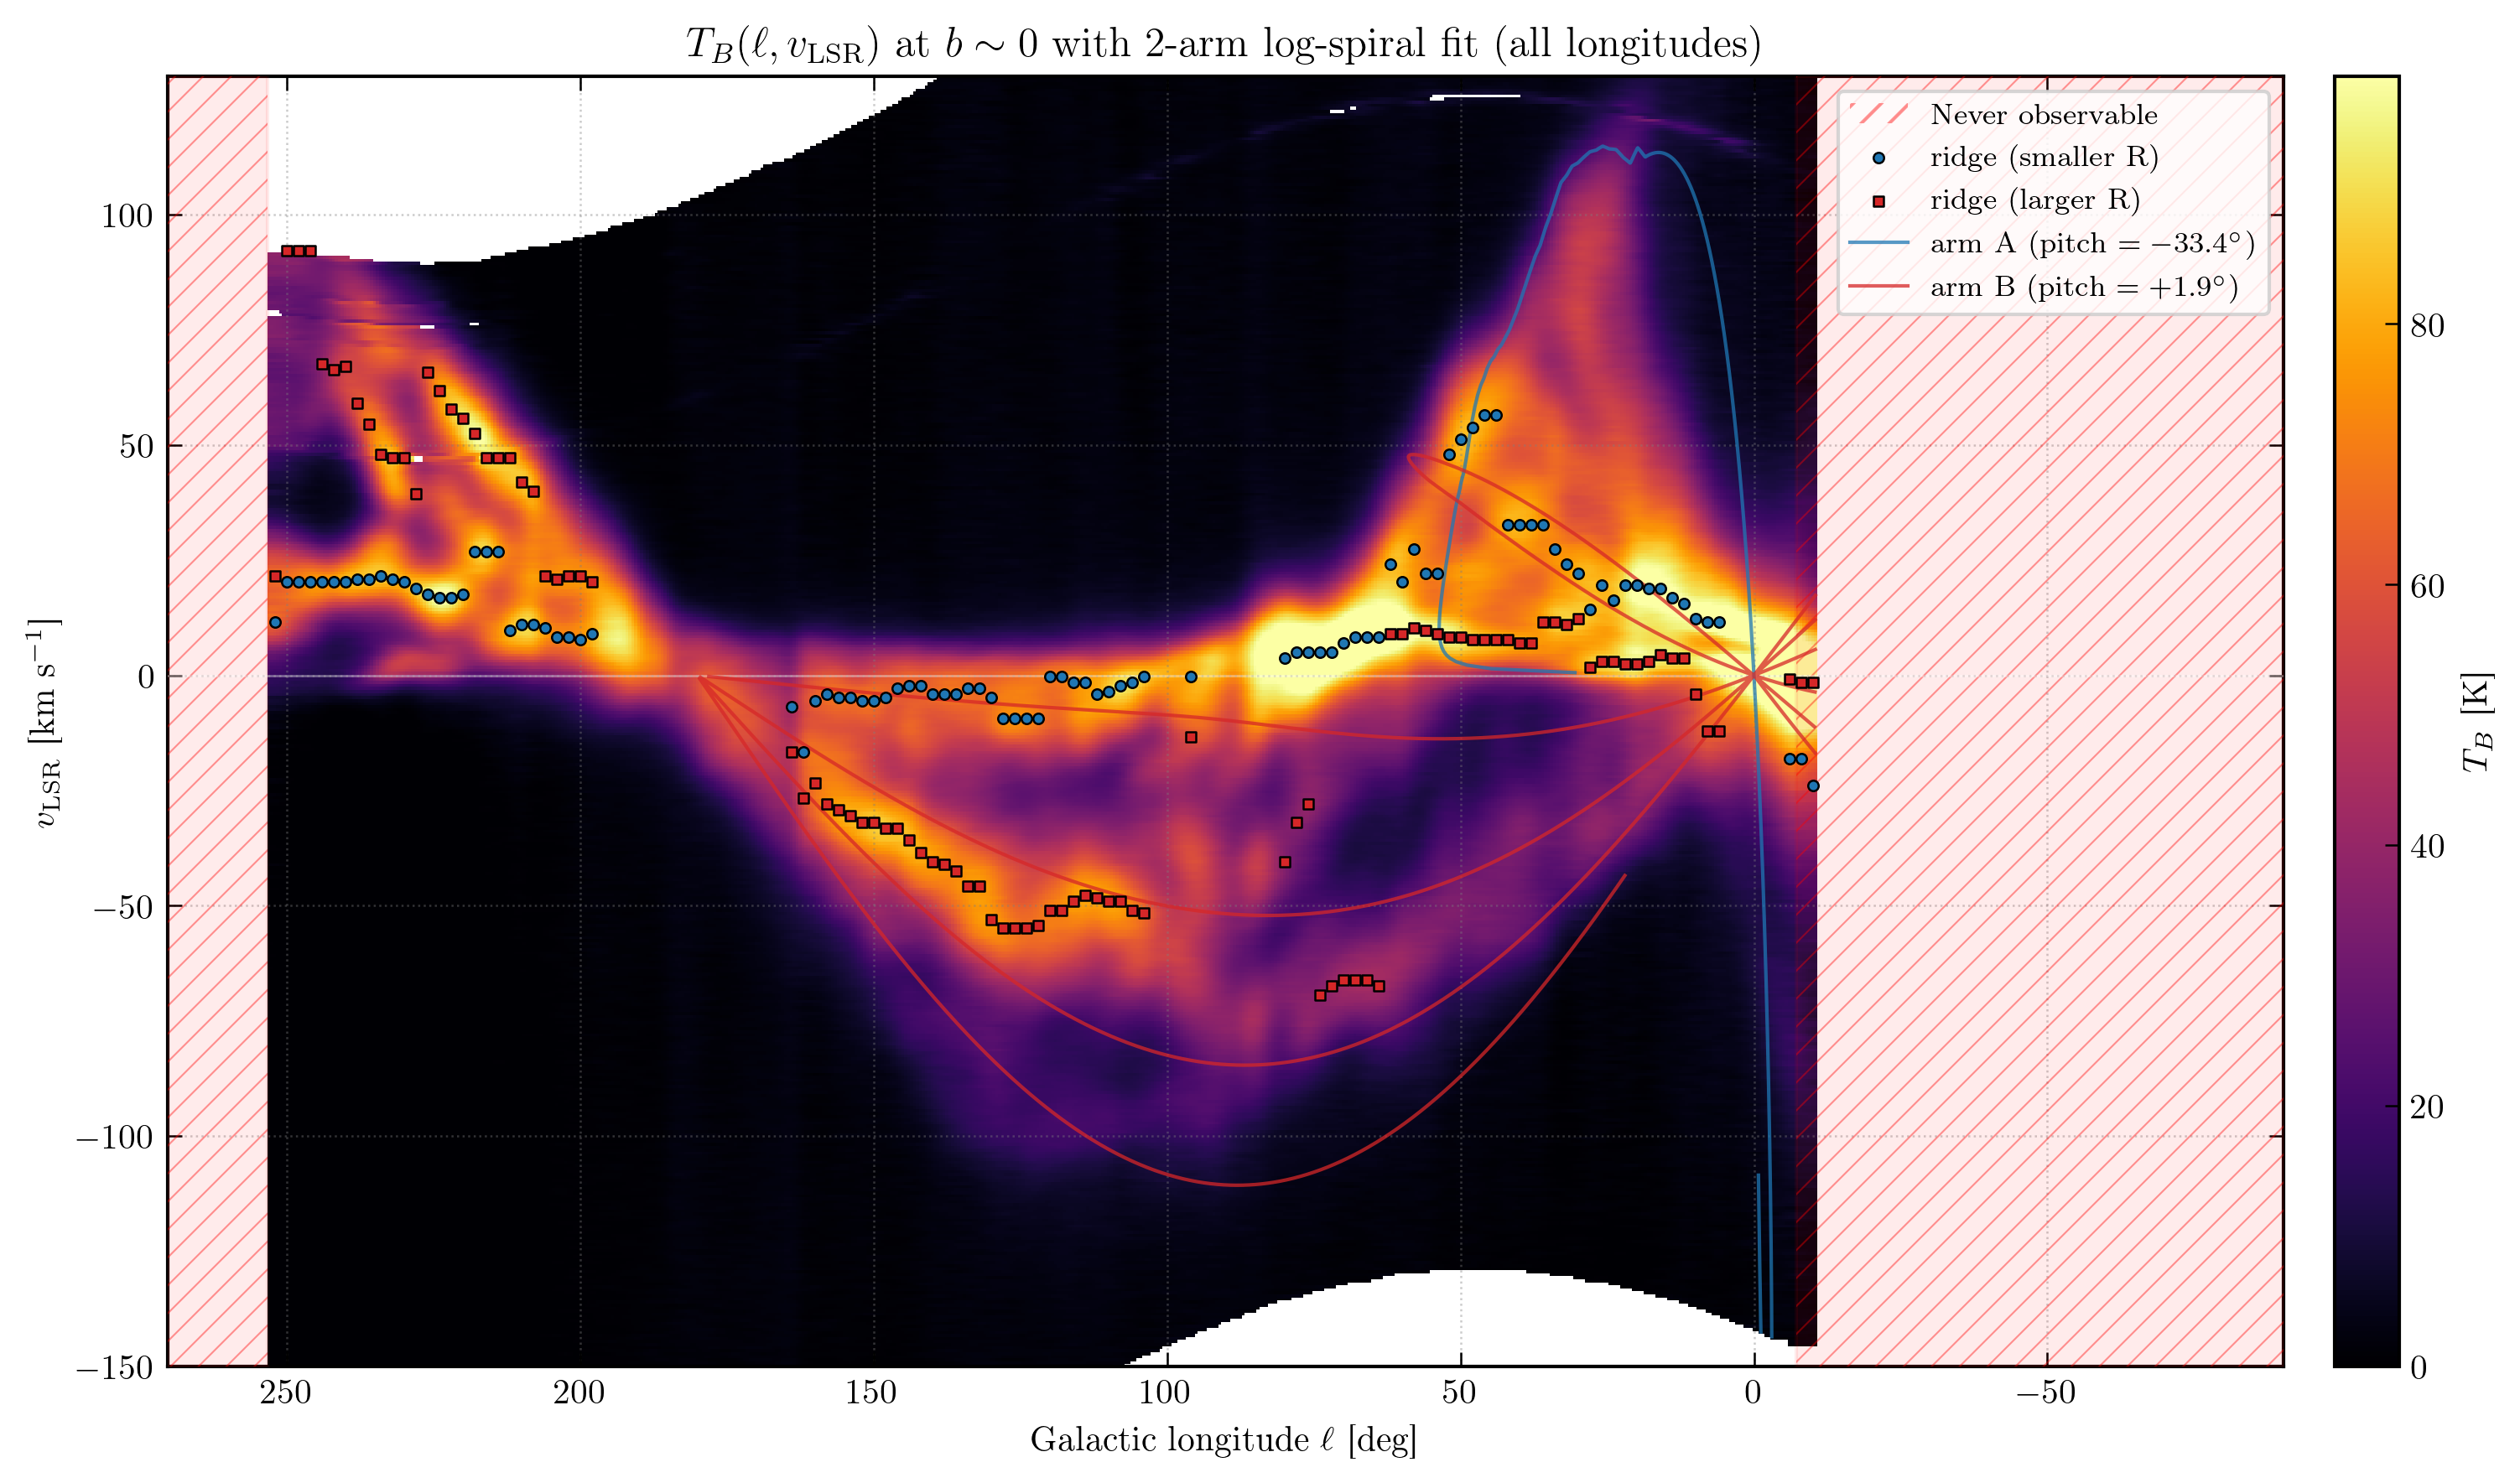

In [7]:
from scipy.signal import find_peaks

# --- Full-disk V(R): measured inside R_sun, flat outside -------------------
def V_full(R_arr):
    R_arr = np.atleast_1d(np.asarray(R_arr, dtype=float))
    Rc = np.clip(R_arr, R_INVERT_MIN, R_SUN_KPC)
    V_in = np.interp(Rc, R_for_interp, V_for_interp)
    return np.where(R_arr >= R_SUN_KPC, V_SUN_KMS, V_in)


R_TRACE_MAX_KPC      = 18.0
L_SAMPLE_STEP_DEG    = 2.0
PEAK_MIN_SEP_KMS     = 10.0
PEAK_MIN_FRAC_OF_MAX = 0.10
SIN_L_FLOOR          = 0.02   # skip l within ~1 deg of 0 or 180

l_full_grid = np.arange(np.floor(l_fine.min()),
                        np.ceil(l_fine.max()) + 1e-9,
                        L_SAMPLE_STEP_DEG)
peak_min_sep_chan = max(int(round(PEAK_MIN_SEP_KMS / dv_kms)), 1)


def top2_peaks(l_deg):
    j = int(np.argmin(np.abs(l_fine - l_deg)))
    spec = lv_image[:, j].astype(float)
    edge_ok = (np.abs(v_lsr) < V_BAND_MAX_KMS)
    spec_use = np.where(edge_ok & np.isfinite(spec), spec, -np.inf)
    sig_max = float(np.nanmax(spec_use))
    if not np.isfinite(sig_max) or sig_max <= 0:
        return []
    pk_idx, _ = find_peaks(spec_use,
                           height=PEAK_MIN_FRAC_OF_MAX * sig_max,
                           distance=peak_min_sep_chan)
    if pk_idx.size == 0:
        return []
    top = pk_idx[np.argsort(spec_use[pk_idx])[-2:]]
    return [(float(l_deg), float(v_lsr[i])) for i in top]


def lv_to_Rphi(l_deg, v_obs):
    # Invert (l, v_LSR) -> (R, phi) via full-disk V(R), near branch inside R_sun.
    l_rad = np.deg2rad(l_deg)
    sin_l, cos_l = np.sin(l_rad), np.cos(l_rad)
    if abs(sin_l) < SIN_L_FLOOR:
        return np.nan, np.nan
    R_fine = np.linspace(R_INVERT_MIN, R_TRACE_MAX_KPC, 2000)
    v_at_R = (V_full(R_fine) / R_fine - V_SUN_KMS / R_SUN_KPC) \
             * R_SUN_KPC * sin_l
    order = np.argsort(v_at_R)
    v_sorted, R_sorted = v_at_R[order], R_fine[order]
    if v_obs < v_sorted[0] or v_obs > v_sorted[-1]:
        return np.nan, np.nan
    R = float(np.interp(v_obs, v_sorted, R_sorted))
    disc = R ** 2 - R_SUN_KPC ** 2 * sin_l ** 2
    if disc < 0:
        return np.nan, np.nan
    sqrt_disc = np.sqrt(disc)
    if R >= R_SUN_KPC:
        d = R_SUN_KPC * cos_l + sqrt_disc
    else:
        d = R_SUN_KPC * cos_l - sqrt_disc
        if d <= 0:
            d = R_SUN_KPC * cos_l + sqrt_disc
    if d <= 0:
        return np.nan, np.nan
    x_gc = R_SUN_KPC - d * cos_l
    y_gc = d * sin_l
    return R, float(np.arctan2(y_gc, x_gc))


# --- Sweep all longitudes; collect smaller-R / larger-R per column ---------
inner_l, inner_v, inner_R, inner_phi = [], [], [], []
outer_l, outer_v, outer_R, outer_phi = [], [], [], []

for l_deg in l_full_grid:
    peaks = top2_peaks(l_deg)
    if len(peaks) < 2:
        continue
    converted = []
    for l, v in peaks:
        R, phi = lv_to_Rphi(l, v)
        if np.isfinite(R) and np.isfinite(phi):
            converted.append((l, v, R, phi))
    if len(converted) < 2:
        continue
    converted.sort(key=lambda t: t[2])
    (li, vi, Ri, pi), (lo, vo, Ro, po) = converted[0], converted[-1]
    inner_l.append(li); inner_v.append(vi); inner_R.append(Ri); inner_phi.append(pi)
    outer_l.append(lo); outer_v.append(vo); outer_R.append(Ro); outer_phi.append(po)

inner_l   = np.array(inner_l);   inner_v   = np.array(inner_v)
inner_R   = np.array(inner_R);   inner_phi = np.array(inner_phi)
outer_l   = np.array(outer_l);   outer_v   = np.array(outer_v)
outer_R   = np.array(outer_R);   outer_phi = np.array(outer_phi)
print(f"extracted ridge pairs at {inner_l.size} longitudes "
      f"(out of {l_full_grid.size} sampled)")


# --- Log-spiral fit: ln(R) = ln(R_0) + kappa * phi -------------------------
def fit_log_spiral(R, phi):
    if R.size < 2:
        return None
    slope, intercept = np.polyfit(phi, np.log(R), 1)
    return dict(kappa=float(slope), R0=float(np.exp(intercept)),
                pitch_deg=float(np.rad2deg(np.arctan(slope))))


fit_A = fit_log_spiral(inner_R, inner_phi)
fit_B = fit_log_spiral(outer_R, outer_phi)
print(f"arm A (smaller R): pitch = {fit_A['pitch_deg']:+.2f} deg, "
      f"R_0 = {fit_A['R0']:.2f} kpc  (N = {inner_R.size})")
print(f"arm B (larger  R): pitch = {fit_B['pitch_deg']:+.2f} deg, "
      f"R_0 = {fit_B['R0']:.2f} kpc  (N = {outer_R.size})")


# --- Forward-project fitted arms back to (l, v) ----------------------------
# --- Accessibility mask: cells where the lv_image strip actually has data.
lv_data_mask = np.isfinite(lv_image) & (lv_image != 0)
L_MIN_SURVEY = float(l_fine[lv_data_mask.any(axis=0)].min()) if lv_data_mask.any() else float(l_fine.min())
L_MAX_SURVEY = float(l_fine[lv_data_mask.any(axis=0)].max()) if lv_data_mask.any() else float(l_fine.max())
V_MIN_SURVEY = float(v_lsr.min())
V_MAX_SURVEY = float(v_lsr.max())
V_LSR_ASC = v_lsr[0] < v_lsr[-1]
L_JUMP_BREAK_DEG = 30.0


def arm_to_lv_from_fit(fit, phi_range=(-5*np.pi, 5*np.pi), n_phi=8000):
    phi = np.linspace(phi_range[0], phi_range[1], n_phi)
    R = fit["R0"] * np.exp(fit["kappa"] * phi)
    ok = (R > 0.2) & (R < R_TRACE_MAX_KPC)
    R, phi = R[ok], phi[ok]
    if R.size == 0:
        return np.array([]), np.array([])
    x_gc = R * np.cos(phi); y_gc = R * np.sin(phi)
    x_h = R_SUN_KPC - x_gc; y_h = y_gc
    l_rad = np.arctan2(y_h, x_h)
    l_deg = (np.rad2deg(l_rad) + 180.0) % 360.0 - 180.0
    V = V_full(R)
    v_arm = (V / R - V_SUN_KMS / R_SUN_KPC) * R_SUN_KPC * np.sin(l_rad)

    # Accessibility: inside survey (l, v) box and inside observed lv strip.
    in_box = ((l_deg >= L_MIN_SURVEY) & (l_deg <= L_MAX_SURVEY)
              & (v_arm >= V_MIN_SURVEY) & (v_arm <= V_MAX_SURVEY))
    l_idx = np.searchsorted(l_fine, l_deg).clip(0, lv_data_mask.shape[1] - 1)
    if V_LSR_ASC:
        v_idx = np.searchsorted(v_lsr, v_arm).clip(0, lv_data_mask.shape[0] - 1)
    else:
        v_idx = np.searchsorted(-v_lsr, -v_arm).clip(0, lv_data_mask.shape[0] - 1)
    in_strip = lv_data_mask[v_idx, l_idx]
    keep = in_box & in_strip

    l_out = np.where(keep, l_deg, np.nan)
    v_out = np.where(keep, v_arm, np.nan)
    # Break the line where l wraps from ~+180 to ~-180 (2*pi turn in phi).
    dl = np.zeros_like(l_out)
    dl[1:] = np.abs(np.diff(l_out))
    big_jump = dl > L_JUMP_BREAK_DEG
    l_out[big_jump] = np.nan
    v_out[big_jump] = np.nan
    return l_out, v_out


l_arm_A, v_arm_A = arm_to_lv_from_fit(fit_A)
l_arm_B, v_arm_B = arm_to_lv_from_fit(fit_B)


# --- Plot ------------------------------------------------------------------
fig, ax = plot_lv_strip(
    l_fine, v_lsr, lv_image,
    title=(r"$T_B(\ell, v_{\rm LSR})$ at $b\sim 0$ with 2-arm log-spiral fit "
           r"(all longitudes)"),
    cbar_label=r"$T_B$ [K]",
)
ax.axhline(0.0, color="w", lw=LW_FINE, alpha=ALPHA_FAINT, zorder=4)

ax.scatter(inner_l, inner_v, s=SS_FINE, color="C0", edgecolor="k",
           linewidth=LW_FINE, zorder=5, label="ridge (smaller R)")
ax.scatter(outer_l, outer_v, s=SS_FINE, color="C3", edgecolor="k",
           linewidth=LW_FINE, marker="s", zorder=5, label="ridge (larger R)")

ax.plot(l_arm_A, v_arm_A, lw=LW_LIGHT, color="C0", alpha=ALPHA_STANDARD,
        zorder=4, label=rf"arm A (pitch $= {fit_A['pitch_deg']:+.1f}^\circ$)")
ax.plot(l_arm_B, v_arm_B, lw=LW_LIGHT, color="C3", alpha=ALPHA_STANDARD,
        zorder=4, label=rf"arm B (pitch $= {fit_B['pitch_deg']:+.1f}^\circ$)")

ax.legend(loc="upper right", fontsize="small")
plt.show()


### Where the 2-arm fit fails

The fitted spirals look clean as overlays, but the procedure is fragile
in three regimes the lab manual explicitly warns about (HI1.tex
lines 478-480):

1. **Arm crossings in $(\ell, v)$ space.** As a log spiral wraps in
   $\phi$, its forward-projected trace in $(\ell, v_{\rm LSR})$ folds
   back on itself: a single arm can cross the same $\ell$ at two
   different $v$, and two different arms can cross each other at a
   point. Near a crossing the "smaller-$R$ vs larger-$R$" split flips,
   so the two arms exchange points across the crossing and the OLS fit
   is pulled toward an averaged geometry that doesn't really describe
   either arm.

2. **Peak coincidence when two arms overlap in $v_{\rm LSR}$.**
   `find_peaks` returns local maxima that are separated by at least
   ~10 km/s. When two physical arms project to within a beam-broadened
   line width of each other, the algorithm sees a single peak and
   returns either an unrelated secondary maximum (often a noise bump or
   the tangent-point shoulder) or nothing at all for the second slot.
   Both arms then collapse onto the same ridge for those longitudes,
   and the fit lifetimes biases toward the brighter arm's geometry.

3. **Kinematic-distance ambiguity at the conversion step.** Even when
   the two peaks are well separated, mapping each $(\ell, v)$ to a
   single galactocentric $(R, \phi)$ requires choosing a heliocentric
   branch. We adopt the near branch inside the solar circle, but a
   real inner-Galaxy peak may belong to the far branch. The wrong
   branch puts the same $R$ at a mirror-image $\phi$, dragging
   $\ln R$-vs-$\phi$ residuals and giving a pitch angle that is biased
   (typically *flatter* in magnitude than the true value).

Secondary failure modes that compound the above:

* **Velocity crowding near the tangent point** ($|v_{\rm LSR}| \to
  v_{\rm max}(\ell)$): emission from a wide range of $R$ piles into a
  narrow $v$ band, so the brightest "ridge" at a given $\ell$ may be
  velocity-crowded gas rather than a coherent arm. The
  $v_{\rm LSR}^{\max}$ envelope itself can masquerade as an arm in the
  fit.
* **Peculiar motions** of 5-15 km/s smear ridges by tens of km/s in
  $v_{\rm LSR}$, which in $(R, \phi)$ space translates to non-trivial
  radial scatter that no single log spiral captures.
* **Beam dilution** at $3.4^\circ$ blends inner-Galaxy arms separated
  by less than $\sim 1$-$2$ kpc into a single broadened ridge, so the
  fit silently averages them.

**What this means for the report.** The fitted pitch angles are
illustrative, not measured. Modern arm geometries (Reid+ 2014/2019)
use maser parallax distances precisely because the $(\ell, v)$
inversion does not have enough information to resolve crossings, peak
coincidences, and the KDA simultaneously. The honest claim is: "the
brighter HI ridges in our $T_B(\ell, v)$ image are broadly consistent
with a $\sim 10^\circ$-$15^\circ$ pitch log spiral, but the two-arm
decomposition is degenerate where the arms cross or where their
velocities coincide, and the fit is unstable in both regimes."


## 7. Top-down kinematic-distance projection

Using the same inversion as sections 5 and 6, every pixel of
$T_B(\ell, v_{\rm LSR})$ can be relocated to a galactocentric Cartesian
position $(x_{\rm gc}, y_{\rm gc})$. Inside the solar circle we adopt
the near branch of the kinematic-distance ambiguity (KDA); outside we
use the unique positive heliocentric solution. The resulting 2D
deposition is smoothed with a Gaussian and shown as a face-on view of
the $b\sim 0$ HI distribution, with the two best-fit log spirals from
section 6 overlaid in their natural $(R, \phi)$ form.

**Caveats.** This is a kinematic-distance projection, so:
- inner-Galaxy gas is collapsed onto only the near branch (the far
  branch is dropped, not split);
- structure is smeared in the radial direction near the
  Sun-GC axis where $\sin\ell \to 0$ and the inversion is degenerate;
- only the $b = 0$ strip contributes -- this is not the full Galactic
  disk surface density.

The figure is meant as a visual aid: real arm tracing in HI uses
independent distances (parallax masers, HI self-absorption) to break
the KDA.


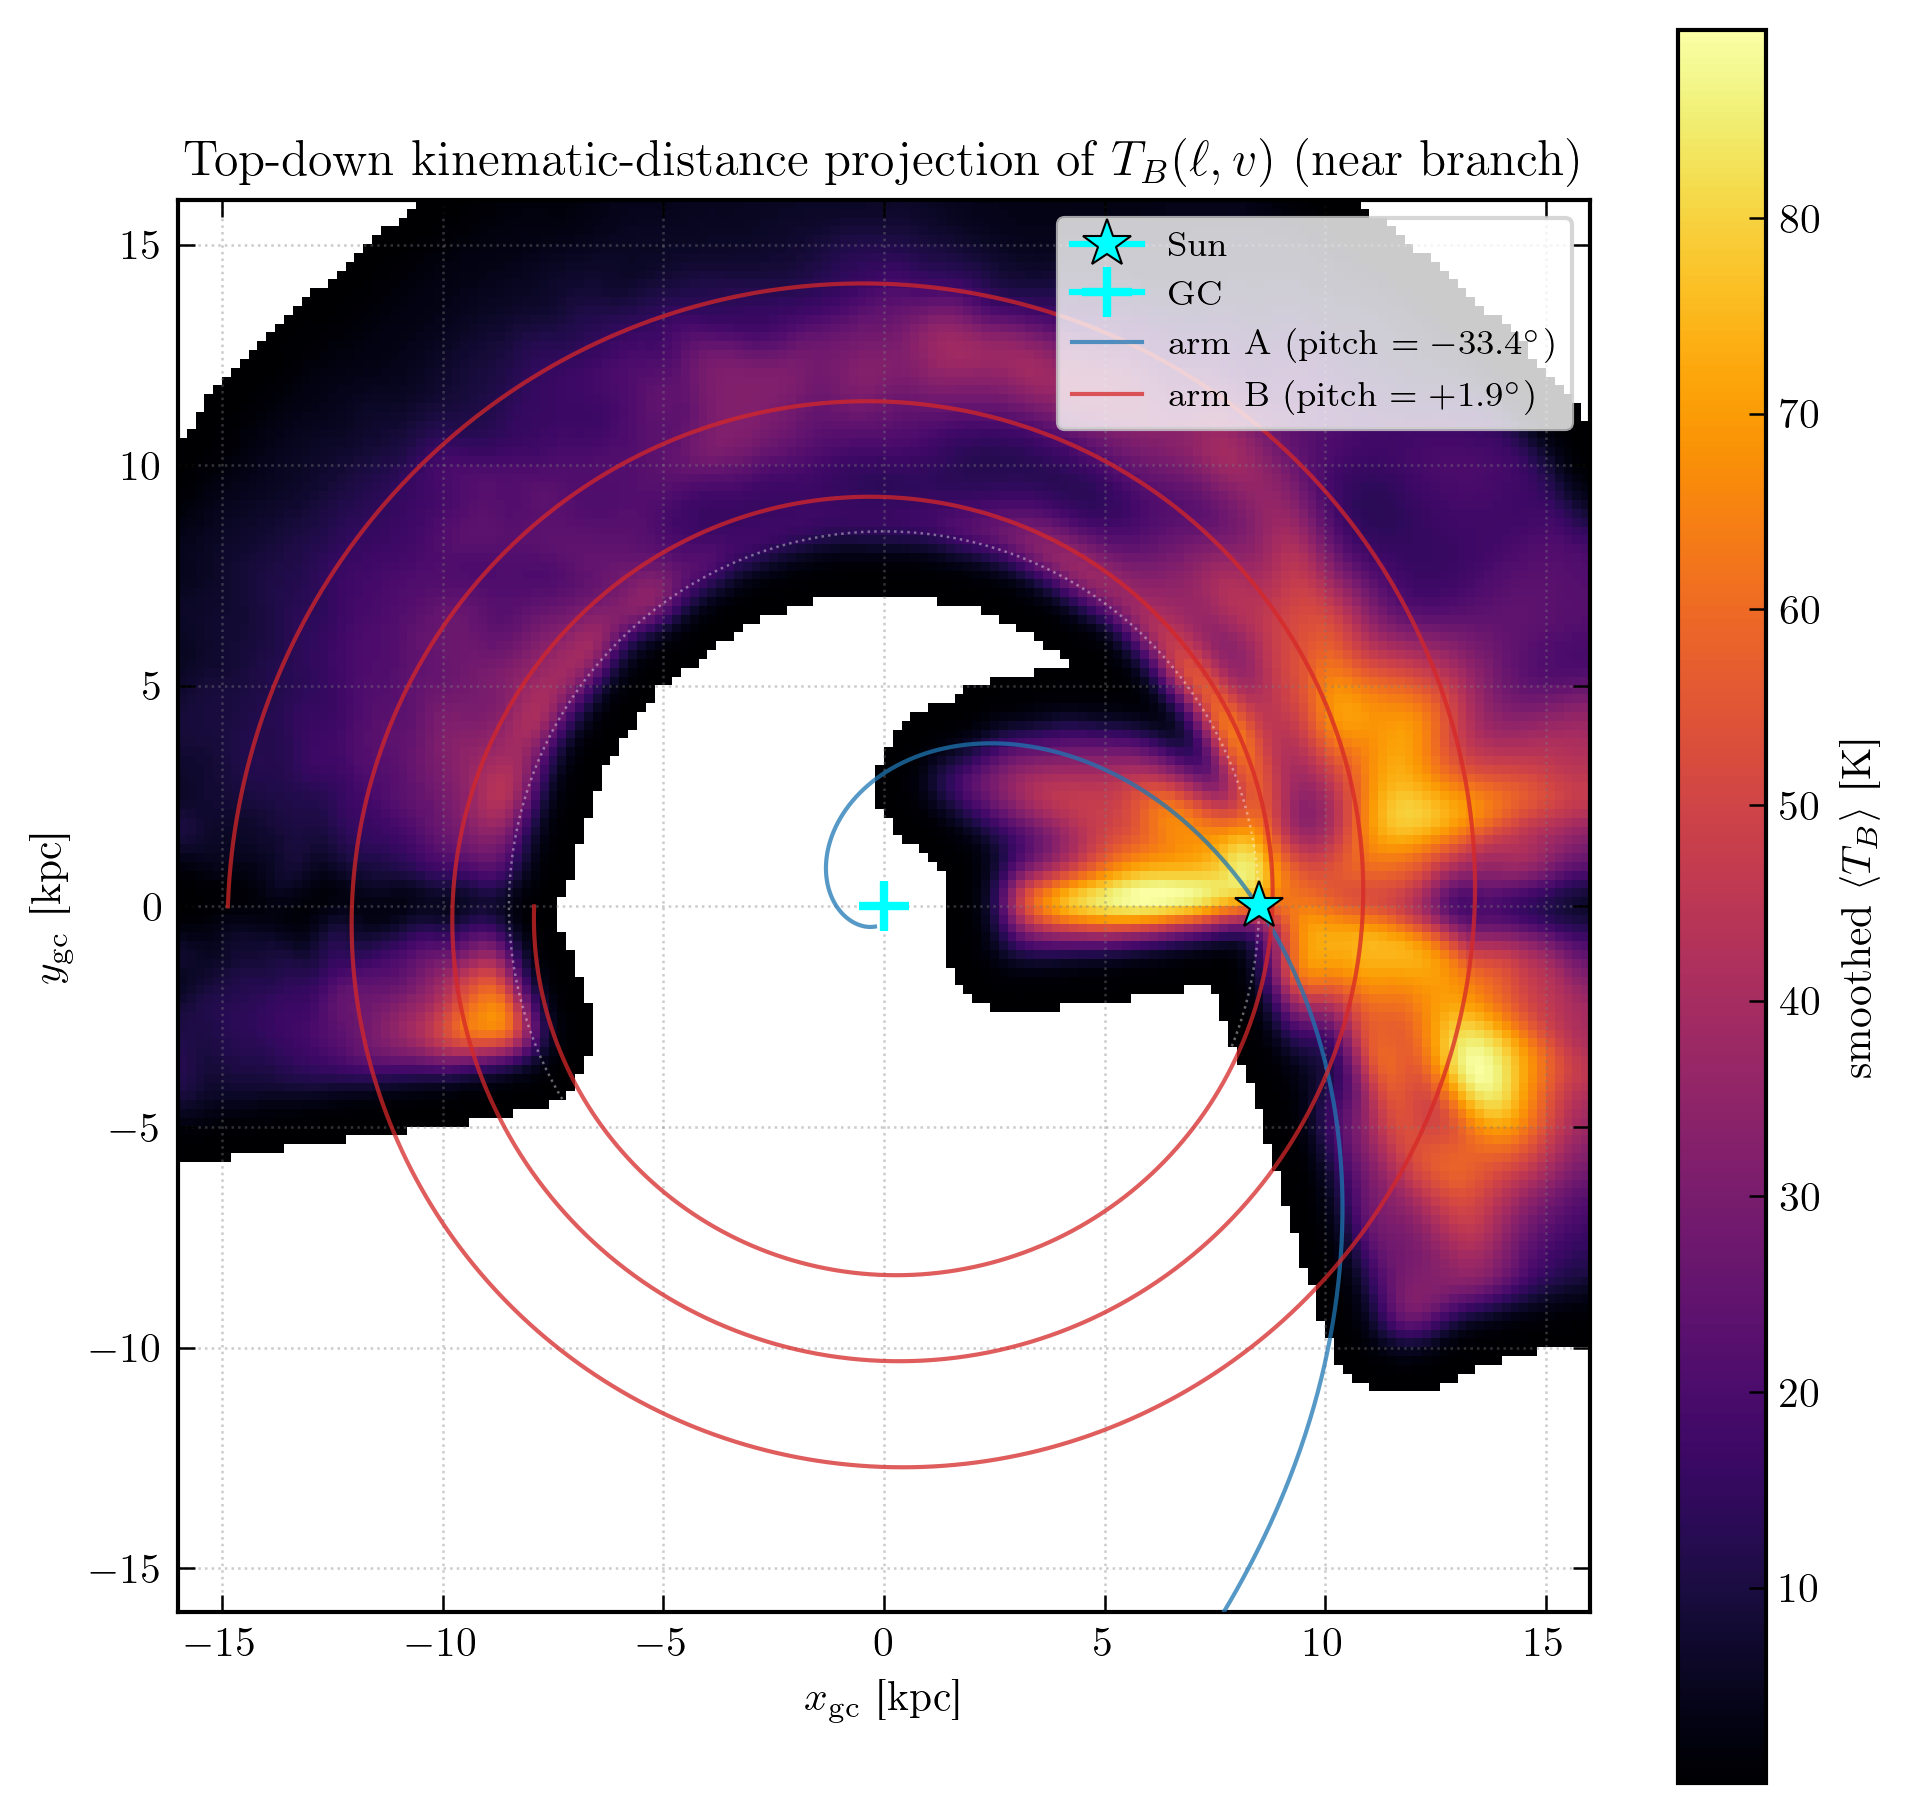

In [8]:
from scipy.ndimage import gaussian_filter

# --- Project lv_image into galactocentric (x, y) on a Cartesian grid -------
XY_MAX_KPC      = 16.0
XY_STEP_KPC     = 0.2
L_PROJ_STEP_DEG = 1.0
GAUSSIAN_SIGMA  = 2.0     # in pixels; ~0.4 kpc at 0.2 kpc/pixel

n_xy   = int(round(2 * XY_MAX_KPC / XY_STEP_KPC))
xy_edges = np.linspace(-XY_MAX_KPC, XY_MAX_KPC, n_xy + 1)

H_T = np.zeros((n_xy, n_xy))   # sum of T_B
H_N = np.zeros((n_xy, n_xy))   # cell count

l_proj_grid = np.arange(L_MIN_SURVEY, L_MAX_SURVEY + 1e-9, L_PROJ_STEP_DEG)
R_inv_grid  = np.linspace(R_INVERT_MIN, R_TRACE_MAX_KPC, 2000)

for l_deg in l_proj_grid:
    l_rad = np.deg2rad(l_deg)
    sin_l, cos_l = np.sin(l_rad), np.cos(l_rad)
    if abs(sin_l) < SIN_L_FLOOR:
        continue
    j = int(np.argmin(np.abs(l_fine - l_deg)))
    spec = lv_image[:, j].astype(float)
    valid = (np.abs(v_lsr) < V_BAND_MAX_KMS) & np.isfinite(spec) & (spec > 0)
    if not valid.any():
        continue
    v_use = v_lsr[valid]
    T_use = spec[valid]
    v_at_R = (V_full(R_inv_grid) / R_inv_grid - V_SUN_KMS / R_SUN_KPC) \
             * R_SUN_KPC * sin_l
    order = np.argsort(v_at_R)
    R_sol = np.interp(v_use, v_at_R[order], R_inv_grid[order],
                      left=np.nan, right=np.nan)
    keep = np.isfinite(R_sol)
    R_sol = R_sol[keep]; T_use = T_use[keep]
    disc = R_sol ** 2 - R_SUN_KPC ** 2 * sin_l ** 2
    keep = disc >= 0
    R_sol = R_sol[keep]; T_use = T_use[keep]; disc = disc[keep]
    sqrt_disc = np.sqrt(disc)
    d_near = R_SUN_KPC * cos_l - sqrt_disc
    d_far  = R_SUN_KPC * cos_l + sqrt_disc
    d = np.where(R_sol >= R_SUN_KPC, d_far, d_near)
    pos = d > 0
    R_sol = R_sol[pos]; d = d[pos]; T_use = T_use[pos]
    x_gc = R_SUN_KPC - d * cos_l
    y_gc = d * sin_l
    ix = np.digitize(x_gc, xy_edges) - 1
    iy = np.digitize(y_gc, xy_edges) - 1
    in_bins = (ix >= 0) & (ix < n_xy) & (iy >= 0) & (iy < n_xy)
    np.add.at(H_T, (iy[in_bins], ix[in_bins]), T_use[in_bins])
    np.add.at(H_N, (iy[in_bins], ix[in_bins]), 1)

# Mean T_B per cell where observed, then smooth.
with np.errstate(invalid="ignore", divide="ignore"):
    H_mean = np.where(H_N > 0, H_T / H_N, 0.0)
H_smooth = gaussian_filter(H_mean, sigma=GAUSSIAN_SIGMA)
H_display = np.where(H_smooth > 0.01, H_smooth, np.nan)

# --- Plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN))
im = ax.imshow(H_display, origin="lower",
               extent=[-XY_MAX_KPC, XY_MAX_KPC, -XY_MAX_KPC, XY_MAX_KPC],
               cmap="inferno", aspect="equal")
plt.colorbar(im, ax=ax, label=r"smoothed $\langle T_B\rangle$ [K]")

# Solar circle
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(R_SUN_KPC * np.cos(theta), R_SUN_KPC * np.sin(theta),
        color="w", lw=LW_FINE, ls=":", alpha=ALPHA_FAINT, zorder=4)

# Sun, GC
ax.plot(R_SUN_KPC, 0, marker="*", markersize=12, color="cyan",
        markeredgecolor="k", markeredgewidth=0.5, zorder=6, label="Sun")
ax.plot(0, 0, marker="+", markersize=12, color="cyan", mew=2, zorder=6,
        label="GC")

# Best-fit spirals from section 6, traced over multiple wraps.
phi_plot = np.linspace(-3 * np.pi, 3 * np.pi, 4000)
for fit, color, label in zip([fit_A, fit_B], ["C0", "C3"], ["arm A", "arm B"]):
    R = fit["R0"] * np.exp(fit["kappa"] * phi_plot)
    ok = (R > 0.5) & (R < R_TRACE_MAX_KPC)
    Rk, pk = R[ok], phi_plot[ok]
    ax.plot(Rk * np.cos(pk), Rk * np.sin(pk),
            color=color, lw=LW_LIGHT, alpha=ALPHA_STANDARD, zorder=5,
            label=rf"{label} (pitch $= {fit['pitch_deg']:+.1f}^\circ$)")

ax.set_xlim(-XY_MAX_KPC, XY_MAX_KPC)
ax.set_ylim(-XY_MAX_KPC, XY_MAX_KPC)
ax.set_xlabel(r"$x_{\rm gc}$ [kpc]")
ax.set_ylabel(r"$y_{\rm gc}$ [kpc]")
ax.legend(loc="upper right", fontsize="small")
ax.set_title(r"Top-down kinematic-distance projection of $T_B(\ell, v)$ "
             r"(near branch)")
plt.show()
